# Phase 1: Build the labeled-frames dataset

Input: GolfDB metadata pickle + 160px video clips.
Output: extracted event frames, MediaPipe keypoints, train/val/test splits.

1. **Filter** GolfDB to driver clips, face-on or down-the-line view
2. **Deduplicate** by (player, youtube_id) — same swing sometimes appears as both slow-mo and normal-speed; we keep the slow-mo version
3. **Extract event frames** at the 8 GolfDB annotated swing events (Address through Finish)
4. **Run MediaPipe pose** on each frame to get 33 landmark keypoints
5. **Detect handedness** per clip (heuristic, recorded but not used for flipping)
6. **Save keypoints** as a parquet file with one row per frame
7. **Player-grouped split** (70/15/15) so no player appears in multiple splits
8. **Write metadata** capturing run parameters and counts

### Packages for all 4 notebooks

In [2]:
pip install mediapipe==0.10.14

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys
!{sys.executable} -m pip install "protobuf==4.25.5" --force-reinstall

Defaulting to user installation because normal site-packages is not writeable
  Using cached protobuf-4.25.5-cp310-abi3-win_amd64.whl.metadata (541 bytes)
Using cached protobuf-4.25.5-cp310-abi3-win_amd64.whl (413 kB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.75.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.5 which is incompatible.
opentelemetry-proto 1.40.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.5 which is incompatible.
xai-sdk 1.12.2 requires protobuf<7,>=5.29.4, but you have protobuf 4.25.5 which is incompatible.

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install Pillow chromadb matplotlib numpy openai opencv-python pandas pydantic "pydantic-ai[openai]" python-dotenv scikit-learn seaborn torch torchvision

Defaulting to user installation because normal site-packages is not writeable
  Using cached protobuf-6.33.6-cp310-abi3-win_amd64.whl.metadata (593 bytes)
Using cached protobuf-6.33.6-cp310-abi3-win_amd64.whl (437 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.5
    Uninstalling protobuf-4.25.5:
      Successfully uninstalled protobuf-4.25.5
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 6.33.6 which is incompatible.

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Setup

In [5]:
import json
from datetime import datetime
from pathlib import Path

import cv2
import mediapipe as mp
import mediapipe.python.solutions.pose as mp_pose
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

PICKLE_PATH = Path('../data/raw/golfDB.pkl')
VIDEOS_DIR = Path('../data/raw/videos_160')
OUT_DIR = Path('../data/processed')
FRAMES_DIR = OUT_DIR / 'frames'
RANDOM_SEED = 42

EVENT_NAMES = ['Address', 'Toe-up', 'Mid-backswing', 'Top',
               'Mid-downswing', 'Impact', 'Mid-followthrough', 'Finish']
NUM_LANDMARKS = 33  # MediaPipe Pose has 33 landmarks

# MediaPipe landmark name → index (the ones we care about)
LM = {
    'nose': 0,
    'left_shoulder': 11, 'right_shoulder': 12,
    'left_elbow': 13, 'right_elbow': 14,
    'left_wrist': 15, 'right_wrist': 16,
    'left_hip': 23, 'right_hip': 24,
    'left_knee': 25, 'right_knee': 26,
    'left_ankle': 27, 'right_ankle': 28,
}

# Pairs to swap when mirroring keypoints (used in Phase 2 augmentation)
LEFT_RIGHT_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10),       # face
    (11, 12), (13, 14), (15, 16),                   # arms
    (17, 18), (19, 20), (21, 22),                   # hands
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),  # legs
]

OUT_DIR.mkdir(parents=True, exist_ok=True)
FRAMES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output directory: {OUT_DIR.resolve()}')

Output directory: C:\@code\GolfAIML\data\processed


## 2. Filter and deduplicate clips

**Filter**: keep only driver swings filmed face-on or down-the-line. These are the views the classifier and coaching agent are designed for.

**Dedup**: GolfDB sometimes contains the same swing as both a normal-speed and a slow-motion clip (same player + same source YouTube video). Keeping both inflates effective sample size without adding signal. We deduplicate by (player, youtube_id), preferring the slow-motion version where available since slow-motion gives more precise event-frame timing.

In [6]:
df = pd.read_pickle(PICKLE_PATH)
df_filtered = df[
    (df['club'] == 'driver') &
    (df['view'].isin(['down-the-line', 'face-on']))
].copy().reset_index(drop=True)

print(f'After view/club filter: {len(df_filtered)} clips, {df_filtered["player"].nunique()} players')
print(f'  Slow-mo split: {df_filtered["slow"].value_counts().to_dict()}')

# Dedup: prefer slow=1 by sorting descending and dropping later duplicates
df_f = (
    df_filtered
    .sort_values('slow', ascending=False)
    .drop_duplicates(['player', 'youtube_id'], keep='first')
    .reset_index(drop=True)
)

n_removed = len(df_filtered) - len(df_f)
print(f'After dedup:           {len(df_f)} clips, {df_f["player"].nunique()} players')
print(f'  Removed {n_removed} duplicate clips')
print(f'  View split: {df_f["view"].value_counts().to_dict()}')
print(f'  Sex split: {df_f["sex"].value_counts().to_dict()}')
print(f'  Slow-mo split: {df_f["slow"].value_counts().to_dict()}')

After view/club filter: 765 clips, 179 players
  Slow-mo split: {0: 403, 1: 362}
After dedup:           345 clips, 179 players
  Removed 420 duplicate clips
  View split: {np.str_('down-the-line'): 199, np.str_('face-on'): 146}
  Sex split: {np.str_('f'): 181, np.str_('m'): 164}
  Slow-mo split: {1: 322, 0: 23}


## 3. Extract event frames and run MediaPipe pose

For each clip, read the 8 event frames listed in `events[1:9]` (events[0] and events[9] are clip boundaries), save the JPEG to disk, and run MediaPipe Pose to get 33 keypoints.

In [7]:
pose_model = mp_pose.Pose(
    static_image_mode=True,
    model_complexity=2,
    enable_segmentation=False,
    min_detection_confidence=0.5,
)

rows = []
failed_clips = []

for i, clip in enumerate(df_f.itertuples()):
    if i % 50 == 0:
        print(f'  Processing clip {i}/{len(df_f)}...')

    video_path = VIDEOS_DIR / f'{clip.id}.mp4'
    if not video_path.exists():
        failed_clips.append((clip.id, 'video missing'))
        continue

    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    events = clip.events
    clip_start = int(events[0])
    event_frames_rel = [int(events[k]) - clip_start for k in range(1, 9)]

    if max(event_frames_rel) >= total_frames or min(event_frames_rel) < 0:
        failed_clips.append((clip.id, 'event frame out of range'))
        cap.release()
        continue

    clip_rows = []
    failed_partway = False
    for event_idx, frame_idx in enumerate(event_frames_rel, start=1):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            failed_clips.append((clip.id, f'could not read frame at event {event_idx}'))
            failed_partway = True
            break

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose_model.process(rgb)

        if results.pose_landmarks is None:
            kp = np.full((NUM_LANDMARKS, 3), np.nan, dtype=np.float32)
        else:
            kp = np.array([
                [lm.x, lm.y, lm.visibility]
                for lm in results.pose_landmarks.landmark
            ], dtype=np.float32)

        frame_filename = f'clip{clip.id:04d}_event{event_idx}.jpg'
        cv2.imwrite(str(FRAMES_DIR / frame_filename), frame)

        clip_rows.append({
            'clip_id': clip.id,
            'player': clip.player,
            'sex': clip.sex,
            'view': clip.view,
            'slow': clip.slow,
            'event_idx': event_idx,
            'label': EVENT_NAMES[event_idx - 1],
            'frame_filename': frame_filename,
            'keypoints': kp,
        })

    cap.release()
    if not failed_partway:
        rows.extend(clip_rows)

pose_model.close()
print(f'\nSuccessful clips: {len(rows) // 8}')
print(f'Failed clips: {len(failed_clips)}')
if failed_clips[:5]:
    print(f'Sample failures: {failed_clips[:5]}')

  Processing clip 0/345...


c:\python312\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


  Processing clip 50/345...
  Processing clip 100/345...
  Processing clip 150/345...
  Processing clip 200/345...
  Processing clip 250/345...
  Processing clip 300/345...

Successful clips: 345
Failed clips: 0


## 4. Detect handedness (record-only, no flipping)

Heuristic detection of left-handed swings. **Recorded for the metadata; no flipping is applied** — see the methodology note in the notebook header.

- **Face-on view**: at Mid-backswing (event_idx 3), check if the average wrist x is to the right of the nose x
- **Down-the-line view**: at Address (event_idx 1), check if the average wrist x is to the left of the hip center x

Both checks rely on body geometry being clear at the chosen reference frame. We saw ~3-15% false positives during testing depending on the heuristic version. The flag is for reporting only.

In [8]:
def detect_handedness(clip_rows, view):
    """View-specific handedness detection. Returns 'R', 'L', or 'unknown'.

    For face-on view: at Mid-backswing (event_idx=3), check if avg wrist x is
    right of nose x (lefty signal).

    For down-the-line view: at Address (event_idx=1), check if avg wrist x is
    left of hip center x (lefty signal).
    """
    if view == 'face-on':
        ref_row = next((r for r in clip_rows if r['event_idx'] == 3), None)
        if ref_row is None:
            return 'unknown'
        kp = ref_row['keypoints']
        if np.isnan(kp).any():
            return 'unknown'
        avg_wrist_x = (kp[LM['left_wrist']][0] + kp[LM['right_wrist']][0]) / 2
        nose_x = kp[LM['nose']][0]
        return 'L' if avg_wrist_x > nose_x else 'R'

    elif view == 'down-the-line':
        ref_row = next((r for r in clip_rows if r['event_idx'] == 1), None)
        if ref_row is None:
            return 'unknown'
        kp = ref_row['keypoints']
        if np.isnan(kp).any():
            return 'unknown'
        avg_wrist_x = (kp[LM['left_wrist']][0] + kp[LM['right_wrist']][0]) / 2
        hip_center_x = (kp[LM['left_hip']][0] + kp[LM['right_hip']][0]) / 2
        return 'L' if avg_wrist_x < hip_center_x else 'R'

    return 'unknown'


clip_to_rows = {}
for r in rows:
    clip_to_rows.setdefault(r['clip_id'], []).append(r)

handedness_by_clip = {}
for clip_id, clip_rows in clip_to_rows.items():
    view = clip_rows[0]['view']
    handedness_by_clip[clip_id] = detect_handedness(clip_rows, view)

for r in rows:
    r['handedness'] = handedness_by_clip.get(r['clip_id'], 'unknown')

counts = pd.Series(list(handedness_by_clip.values())).value_counts()
print(f'Handedness counts (record-only, no flipping): {counts.to_dict()}')

Handedness counts (record-only, no flipping): {'R': 333, 'L': 11, 'unknown': 1}


## 5. Build keypoints.parquet

Flatten each clip's per-event keypoints into one row per frame. Columns: metadata + `kp_x_i`, `kp_y_i`, `kp_v_i` for `i` in `0..32`.

In [9]:
flat_rows = []
for r in rows:
    flat = {
        'clip_id': r['clip_id'],
        'player': r['player'],
        'sex': r['sex'],
        'view': r['view'],
        'slow': r['slow'],
        'handedness': r['handedness'],
        'event_idx': r['event_idx'],
        'label': r['label'],
        'frame_filename': r['frame_filename'],
    }
    for i in range(NUM_LANDMARKS):
        flat[f'kp_x_{i}'] = r['keypoints'][i, 0]
        flat[f'kp_y_{i}'] = r['keypoints'][i, 1]
        flat[f'kp_v_{i}'] = r['keypoints'][i, 2]
    flat_rows.append(flat)

df_kp = pd.DataFrame(flat_rows)
out_path = OUT_DIR / 'keypoints.parquet'
df_kp.to_parquet(out_path, index=False)
print(f'Wrote {len(df_kp)} rows to {out_path}')
df_kp.head()

Wrote 2760 rows to ..\data\processed\keypoints.parquet


,clip_id,player,sex,view,slow,handedness,event_idx,label,frame_filename,kp_x_0,...,kp_v_29,kp_x_30,kp_y_30,kp_v_30,kp_x_31,kp_y_31,kp_v_31,kp_x_32,kp_y_32,kp_v_32
0,1399,KENNY PERRY,m,down-the-line,1,R,1,Address,clip1399_event1.jpg,0.561053,...,0.816038,0.373482,0.965651,0.887343,0.512673,0.924629,0.896824,0.463517,0.965253,0.979659
1,1399,KENNY PERRY,m,down-the-line,1,R,2,Toe-up,clip1399_event2.jpg,0.532345,...,0.866845,0.384401,0.957379,0.884381,0.502987,0.934537,0.938468,0.437501,0.961633,0.980505
2,1399,KENNY PERRY,m,down-the-line,1,R,3,Mid-backswing,clip1399_event3.jpg,0.530872,...,0.837722,0.378789,0.963059,0.908408,0.512849,0.926530,0.946271,0.451025,0.966745,0.985412
3,1399,KENNY PERRY,m,down-the-line,1,R,4,Top,clip1399_event4.jpg,0.541007,...,0.791207,0.379667,0.969024,0.914073,0.516002,0.923873,0.900656,0.451443,0.966204,0.989892
4,1399,KENNY PERRY,m,down-the-line,1,R,5,Mid-downswing,clip1399_event5.jpg,0.540006,...,0.948225,0.375992,0.966570,0.954921,0.524518,0.929098,0.983719,0.455669,0.971069,0.995120


## 6. Player-grouped train/val/test split (70/15/15)

`GroupShuffleSplit` ensures no player appears in more than one split. This matters because a single player may have multiple clips and we don't want trivial leakage from "this player's swing" being learnable across train/test.

In [10]:
clip_df = df_kp[['clip_id', 'player', 'view']].drop_duplicates().reset_index(drop=True)

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_SEED)
trainval_idx, test_idx = next(gss1.split(clip_df, groups=clip_df['player']))
trainval = clip_df.iloc[trainval_idx]
test = clip_df.iloc[test_idx]

# 0.176 of trainval ≈ 0.15 of total → ~70/15/15 overall
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=RANDOM_SEED)
train_idx, val_idx = next(gss2.split(trainval, groups=trainval['player']))
train = trainval.iloc[train_idx]
val = trainval.iloc[val_idx]

splits = {
    'train': train['clip_id'].tolist(),
    'val': val['clip_id'].tolist(),
    'test': test['clip_id'].tolist(),
}

train_p = set(train['player'])
val_p = set(val['player'])
test_p = set(test['player'])
print(f'Train: {len(train)} clips, {len(train_p)} players')
print(f'Val:   {len(val)} clips, {len(val_p)} players')
print(f'Test:  {len(test)} clips, {len(test_p)} players')
print(f'Player overlaps (must all be 0): '
      f'T-V={len(train_p & val_p)}, T-Te={len(train_p & test_p)}, V-Te={len(val_p & test_p)}')

print('\nView distribution per split:')
for name, d in [('train', train), ('val', val), ('test', test)]:
    print(f'  {name}: {d["view"].value_counts().to_dict()}')

with open(OUT_DIR / 'splits.json', 'w') as f:
    json.dump(splits, f, indent=2)
print(f'\nWrote splits to {OUT_DIR / "splits.json"}')

Train: 246 clips, 125 players
Val:   39 clips, 27 players
Test:  60 clips, 27 players
Player overlaps (must all be 0): T-V=0, T-Te=0, V-Te=0

View distribution per split:
  train: {np.str_('down-the-line'): 148, np.str_('face-on'): 98}
  val: {np.str_('down-the-line'): 20, np.str_('face-on'): 19}
  test: {np.str_('down-the-line'): 31, np.str_('face-on'): 29}

Wrote splits to ..\data\processed\splits.json


## 7. Write metadata.json

In [11]:
metadata = {
    'created_at': datetime.now().isoformat(),
    'mediapipe_version': mp.__version__,
    'random_seed': RANDOM_SEED,
    'filters': {'club': 'driver', 'view': ['down-the-line', 'face-on']},
    'dedup_rule': 'keep one clip per (player, youtube_id), prefer slow=1',
    'n_clips_input': len(df_filtered),
    'n_clips_after_dedup': len(df_f),
    'n_clips_succeeded': len(df_kp) // 8,
    'n_clips_failed': len(failed_clips),
    'failed_clips': [(int(cid), msg) for cid, msg in failed_clips],
    'handedness_counts': dict(pd.Series(list(handedness_by_clip.values())).value_counts()),
    'handedness_flipping_applied': False,
    'handedness_note': 'detection recorded but no flipping applied; mirror augmentation done in Phase 2 instead',
    'splits': {k: len(v) for k, v in splits.items()},
}
with open(OUT_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print('Wrote metadata.json')
print(json.dumps(metadata, indent=2, default=str))

Wrote metadata.json
{
  "created_at": "2026-05-12T18:03:26.208300",
  "mediapipe_version": "0.10.14",
  "random_seed": 42,
  "filters": {
    "club": "driver",
    "view": [
      "down-the-line",
      "face-on"
    ]
  },
  "dedup_rule": "keep one clip per (player, youtube_id), prefer slow=1",
  "n_clips_input": 765,
  "n_clips_after_dedup": 345,
  "n_clips_succeeded": 345,
  "n_clips_failed": 0,
  "failed_clips": [],
  "handedness_counts": {
    "R": "333",
    "L": "11",
    "unknown": "1"
  },
  "handedness_flipping_applied": false,
  "handedness_note": "detection recorded but no flipping applied; mirror augmentation done in Phase 2 instead",
  "splits": {
    "train": 246,
    "val": 39,
    "test": 60
  }
}


## 8. Sanity checks

Three quick visualizations to confirm the outputs are sound:

1. Pose keypoints overlaid on a few random frames
2. Keypoint visibility distribution per event (the Top frame typically has the lowest visibility because hands block the face)
3. Sample frames from clips detected as L (informational)

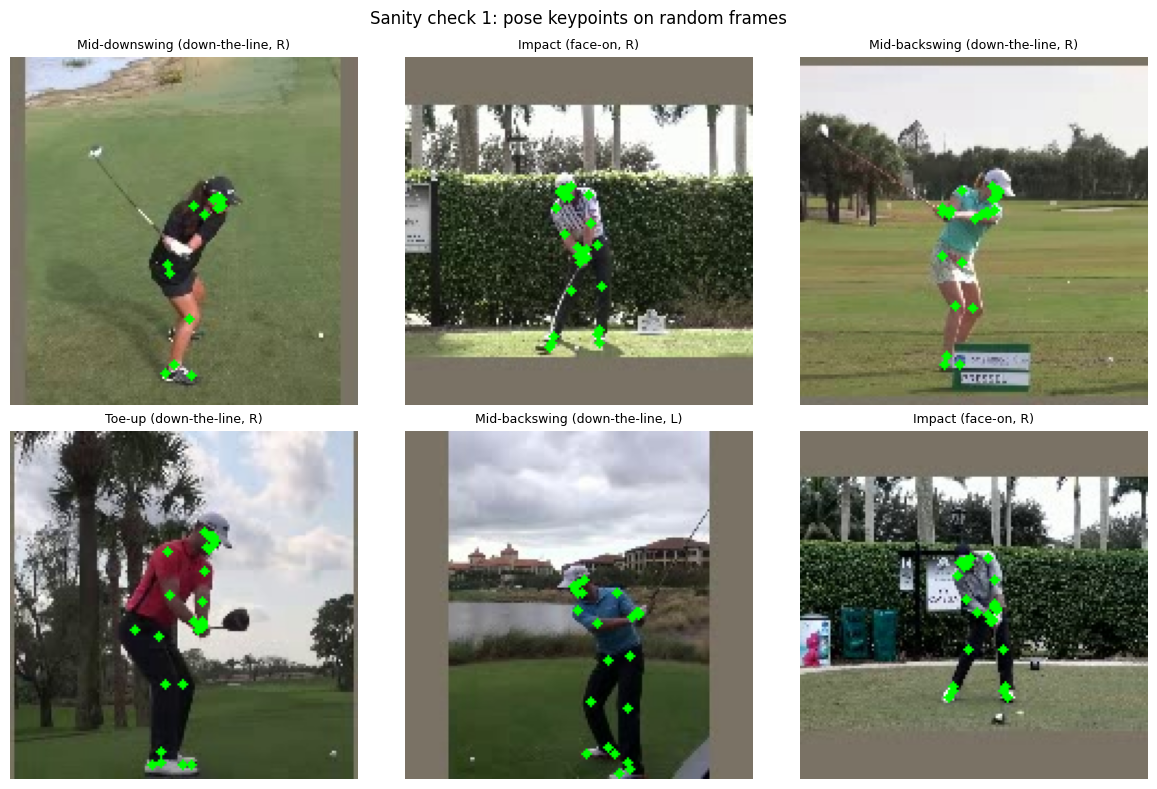

In [12]:
rng = np.random.default_rng(RANDOM_SEED)
sample_idx = rng.choice(len(df_kp), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, idx in zip(axes.flat, sample_idx):
    row = df_kp.iloc[idx]
    img = cv2.imread(str(FRAMES_DIR / row['frame_filename']))
    if img is None:
        ax.axis('off')
        continue
    h, w = img.shape[:2]
    overlay = img.copy()
    for i in range(NUM_LANDMARKS):
        v = row[f'kp_v_{i}']
        if v > 0.5:
            x = int(row[f'kp_x_{i}'] * w)
            y = int(row[f'kp_y_{i}'] * h)
            cv2.circle(overlay, (x, y), 2, (0, 255, 0), -1)
    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{row["label"]} ({row["view"]}, {row["handedness"]})', fontsize=9)
    ax.axis('off')
plt.suptitle('Sanity check 1: pose keypoints on random frames')
plt.tight_layout()
plt.show()

Mean keypoint visibility per event:
                    mean    std
label                          
Address            0.876  0.068
Toe-up             0.868  0.064
Mid-backswing      0.808  0.073
Top                0.840  0.075
Mid-downswing      0.793  0.084
Impact             0.887  0.062
Mid-followthrough  0.789  0.099
Finish             0.783  0.083


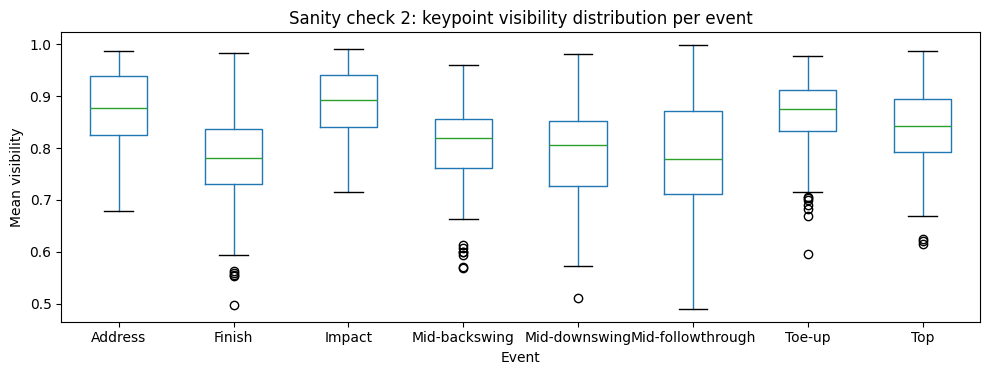

In [13]:
vis_cols = [f'kp_v_{i}' for i in range(NUM_LANDMARKS)]
df_kp['mean_visibility'] = df_kp[vis_cols].mean(axis=1)

vis_by_event = df_kp.groupby('label', sort=False)['mean_visibility'].agg(['mean', 'std'])
print('Mean keypoint visibility per event:')
print(vis_by_event.round(3))

fig, ax = plt.subplots(figsize=(10, 4))
df_kp.boxplot(column='mean_visibility', by='label', ax=ax,
              grid=False, rot=0)
ax.set_title('Sanity check 2: keypoint visibility distribution per event')
ax.set_xlabel('Event')
ax.set_ylabel('Mean visibility')
plt.suptitle('')
plt.tight_layout()
plt.show()